Data directory: /Users/mahriovezmyradova/MultiMed_dataset/German
Available files:
  - train-00000-of-00001.parquet (172.89 MB)
  - test-00000-of-00001.parquet (131.36 MB)
  - eval-00000-of-00001.parquet (33.83 MB)
Loaded train: 1443 samples
Loaded eval: 287 samples
Loaded test: 1091 samples

Split: train
Shape: (1443, 3)
Columns: ['audio', 'text', 'duration']

Data types:
audio        object
text         object
duration    float64
dtype: object

Missing values:
audio       0
text        0
duration    0
dtype: int64

Sample row:
audio       {'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...
text        ich aber was ist mit dir welche weiterbildung ...
duration                                                 13.0
Name: 0, dtype: object

Split: eval
Shape: (287, 3)
Columns: ['audio', 'text', 'duration']

Data types:
audio        object
text         object
duration    float64
dtype: object

Missing values:
audio       0
text        0
duration    0
dtype: int64

Sample row:
audio       {'byt

NotADirectoryError: [Errno 20] Not a directory: '/Users/mahriovezmyradova/MedicalASR-Summarization/data/outputs/text_length_distribution.png'

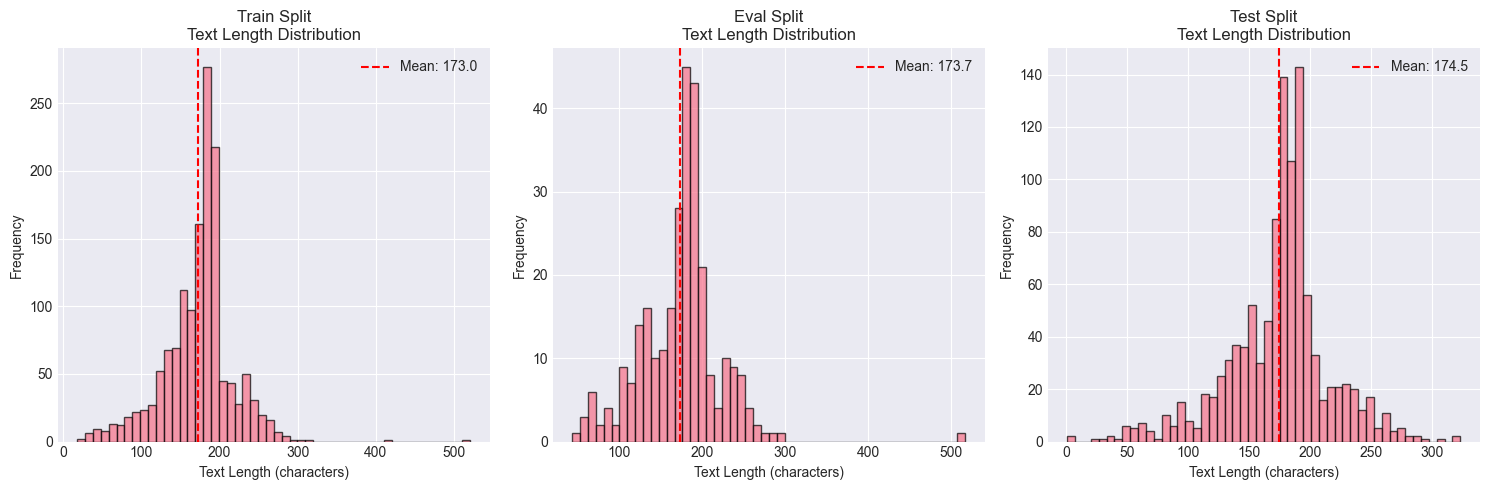

In [1]:
# %% [markdown]
# # Medical Dataset Exploration
# 
# This notebook explores the MultiMed German dataset structure and content.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# %%
# Load config
with open('../config/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

data_dir = Path(config['paths']['data_dir'])
print(f"Data directory: {data_dir}")

# %%
# List available files
files = list(data_dir.glob("*.parquet"))
print("Available files:")
for f in files:
    print(f"  - {f.name} ({f.stat().st_size / 1024 / 1024:.2f} MB)")

# %%
# Load all splits
splits_data = {}
for split in config['dataset']['splits']:
    split_files = list(data_dir.glob(f"{split}-*.parquet"))
    if split_files:
        splits_data[split] = pd.read_parquet(split_files[0])
        print(f"Loaded {split}: {len(splits_data[split])} samples")

# %%
# Explore dataset structure
for split_name, df in splits_data.items():
    print(f"\n{'='*50}")
    print(f"Split: {split_name}")
    print(f"{'='*50}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"\nData types:")
    print(df.dtypes)
    print(f"\nMissing values:")
    print(df.isnull().sum())
    print(f"\nSample row:")
    print(df.iloc[0])

# %%
# Check audio column structure
print("Audio column type:", splits_data['train'][config['dataset']['audio_column']].dtype)
print("\nFirst audio array:")
audio_sample = splits_data['train'][config['dataset']['audio_column']].iloc[0]
print(f"Type: {type(audio_sample)}")
if hasattr(audio_sample, '__dict__'):
    print("Attributes:", audio_sample.__dict__.keys())

# %%
# Extract audio information
def extract_audio_info(df, audio_col='audio'):
    """Extract audio information from dataset."""
    info = {
        'has_audio': [],
        'audio_type': [],
        'sample_rate': [],
        'duration': []
    }
    
    for item in df[audio_col]:
        if hasattr(item, 'keys'):
            # Check if it's a dictionary-like object
            info['has_audio'].append('array' in item or 'bytes' in str(item))
            info['audio_type'].append(type(item))
            
            # Try to get sample rate
            if hasattr(item, '__dict__'):
                info['sample_rate'].append(getattr(item, 'sampling_rate', None))
            else:
                info['sample_rate'].append(None)
                
            # Try to calculate duration
            if hasattr(item, '__dict__') and hasattr(item, 'array'):
                duration = len(item['array']) / item['sampling_rate'] if 'sampling_rate' in item else None
                info['duration'].append(duration)
            else:
                info['duration'].append(None)
        else:
            info['has_audio'].append(False)
            info['audio_type'].append(None)
            info['sample_rate'].append(None)
            info['duration'].append(None)
    
    return pd.DataFrame(info)

# %%
# Analyze text column
for split_name, df in splits_data.items():
    if config['dataset']['text_column'] in df.columns:
        print(f"\n{split_name} - Text Analysis:")
        texts = df[config['dataset']['text_column']].astype(str)
        
        print(f"  Total samples: {len(texts)}")
        print(f"  Missing texts: {texts.isnull().sum()}")
        
        # Text length statistics
        text_lengths = texts.str.len()
        print(f"  Text length (chars):")
        print(f"    Min: {text_lengths.min()}")
        print(f"    Max: {text_lengths.max()}")
        print(f"    Mean: {text_lengths.mean():.1f}")
        print(f"    Std: {text_lengths.std():.1f}")
        
        # Word count statistics
        word_counts = texts.str.split().str.len()
        print(f"  Word count:")
        print(f"    Min: {word_counts.min()}")
        print(f"    Max: {word_counts.max()}")
        print(f"    Mean: {word_counts.mean():.1f}")
        
        # Sample texts
        print(f"\n  Sample texts:")
        for i in range(min(3, len(texts))):
            print(f"    {i+1}. {texts.iloc[i][:100]}...")

# %%
# Visualize text length distribution
fig, axes = plt.subplots(1, len(splits_data), figsize=(15, 5))

for idx, (split_name, df) in enumerate(splits_data.items()):
    if config['dataset']['text_column'] in df.columns:
        texts = df[config['dataset']['text_column']].astype(str)
        text_lengths = texts.str.len()
        
        ax = axes[idx] if len(splits_data) > 1 else axes
        ax.hist(text_lengths, bins=50, alpha=0.7, edgecolor='black')
        ax.set_title(f'{split_name.capitalize()} Split\nText Length Distribution')
        ax.set_xlabel('Text Length (characters)')
        ax.set_ylabel('Frequency')
        ax.axvline(text_lengths.mean(), color='red', linestyle='--', 
                  label=f'Mean: {text_lengths.mean():.1f}')
        ax.legend()

plt.tight_layout()
plt.savefig('../data/outputs/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
# Save dataset statistics
stats = {}
for split_name, df in splits_data.items():
    if config['dataset']['text_column'] in df.columns:
        texts = df[config['dataset']['text_column']].astype(str)
        stats[split_name] = {
            'samples': len(df),
            'text_mean_length': texts.str.len().mean(),
            'text_std_length': texts.str.len().std(),
            'word_mean_count': texts.str.split().str.len().mean(),
            'missing_texts': texts.isnull().sum()
        }

stats_df = pd.DataFrame(stats).T
stats_df.to_csv('../data/outputs/dataset_statistics.csv')
print("Dataset statistics saved to data/outputs/dataset_statistics.csv")
print(stats_df)

# %%
# Check for special medical terms
medical_keywords = ['patient', 'arzt', 'krankheit', 'medikament', 'behandlung', 
                    'symptom', 'diagnose', 'therapie', 'untersuchung', 'klinik']

for split_name, df in splits_data.items():
    if config['dataset']['text_column'] in df.columns:
        texts = df[config['dataset']['text_column']].astype(str).str.lower()
        
        print(f"\n{'-'*40}")
        print(f"Medical Keywords in {split_name}:")
        print(f"{'-'*40}")
        
        for keyword in medical_keywords:
            count = texts.str.contains(keyword).sum()
            percentage = (count / len(texts)) * 100
            print(f"{keyword}: {count} ({percentage:.1f}%)")